# Project - Anticipez les besoins en consommation électrique de bâtiments

Nous avons nettoyé et réaliser une courte analyse exploratoire dans le premier notebook. Ici nous allons procéder à la modélisation et aux tests des différents modéles de prédiction

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import time

#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, make_scorer 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor



## Objectif

### Candidats target
- **prédire la consommation totale d’énergie de bâtiments:** `SiteEnergyUse(kBtu)`

  La quantité annuelle d'énergie consommée par le bien, toutes sources d'énergie confondues.
  Unité utilisée : **kBtu** = Kilo British Thermal Units / Kilo d'unités thermiques britanniques

- **prédire les émissions de CO₂**: `TotalGHGEmissions`

   La quantité totale d'émission de gaz à effet de serre, y compris le dioxyde de carbone, le méthane et l'oxyde nitreux,
   rejetée dans   l'atmosphère à la suite de la consommation d'énergie sur le site, mesurée en tonne d'équivalent dioxyde de carbone.

## Acquérir des données propres

In [2]:
df = pd.read_csv('building_energy_cleaned.csv')
df.head()

,Age,BuildingType,PrimaryPropertyType,NumberofBuildings,NumberofFloors,LargestPropertyUseType,SteamUse(kBtu)_Usage,Electricity(kBtu)_Usage,NaturalGas(kBtu)_Usage,TotalUseTypeNumber,RateParking,RateBuilding,RatePerFloors,RatePerBuildings,log_SiteEnergyUse(kBtu),log_TotalGHGEmissions,log_PropertyGFATotal
0,89,NonResidential,Residential,1.0,12,Residential,1,1,1,1,0.0000,1.0000,7369.5000,88434.0,15.793246,5.525373,11.390023
1,20,NonResidential,Residential,1.0,11,Residential,0,1,1,3,0.1455,0.8545,9415.0909,103566.0,15.942305,5.693261,11.547974
2,90,NonResidential,Residential,1.0,10,Residential,1,1,1,1,0.0000,1.0000,6132.0000,61320.0,15.731637,5.660979,11.023878
3,90,NonResidential,Residential,1.0,11,Residential,0,1,1,1,0.0000,1.0000,7546.1818,83008.0,15.566239,5.176940,11.326704
4,90,NonResidential,Other,1.0,8,Other,1,1,1,1,0.0000,1.0000,12845.1250,102761.0,15.655764,5.404972,11.540171


In [3]:
df.columns.tolist()

['Age',
 'BuildingType',
 'PrimaryPropertyType',
 'NumberofBuildings',
 'NumberofFloors',
 'LargestPropertyUseType',
 'SteamUse(kBtu)_Usage',
 'Electricity(kBtu)_Usage',
 'NaturalGas(kBtu)_Usage',
 'TotalUseTypeNumber',
 'RateParking',
 'RateBuilding',
 'RatePerFloors',
 'RatePerBuildings',
 'log_SiteEnergyUse(kBtu)',
 'log_TotalGHGEmissions',
 'log_PropertyGFATotal']

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1378 entries, 0 to 1377
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      1378 non-null   int64  
 1   BuildingType             1378 non-null   object 
 2   PrimaryPropertyType      1378 non-null   object 
 3   NumberofBuildings        1378 non-null   float64
 4   NumberofFloors           1378 non-null   int64  
 5   LargestPropertyUseType   1378 non-null   object 
 6   SteamUse(kBtu)_Usage     1378 non-null   int64  
 7   Electricity(kBtu)_Usage  1378 non-null   int64  
 8   NaturalGas(kBtu)_Usage   1378 non-null   int64  
 9   TotalUseTypeNumber       1378 non-null   int64  
 10  RateParking              1378 non-null   float64
 11  RateBuilding             1378 non-null   float64
 12  RatePerFloors            1378 non-null   float64
 13  RatePerBuildings         1378 non-null   float64
 14  log_SiteEnergyUse(kBtu) 

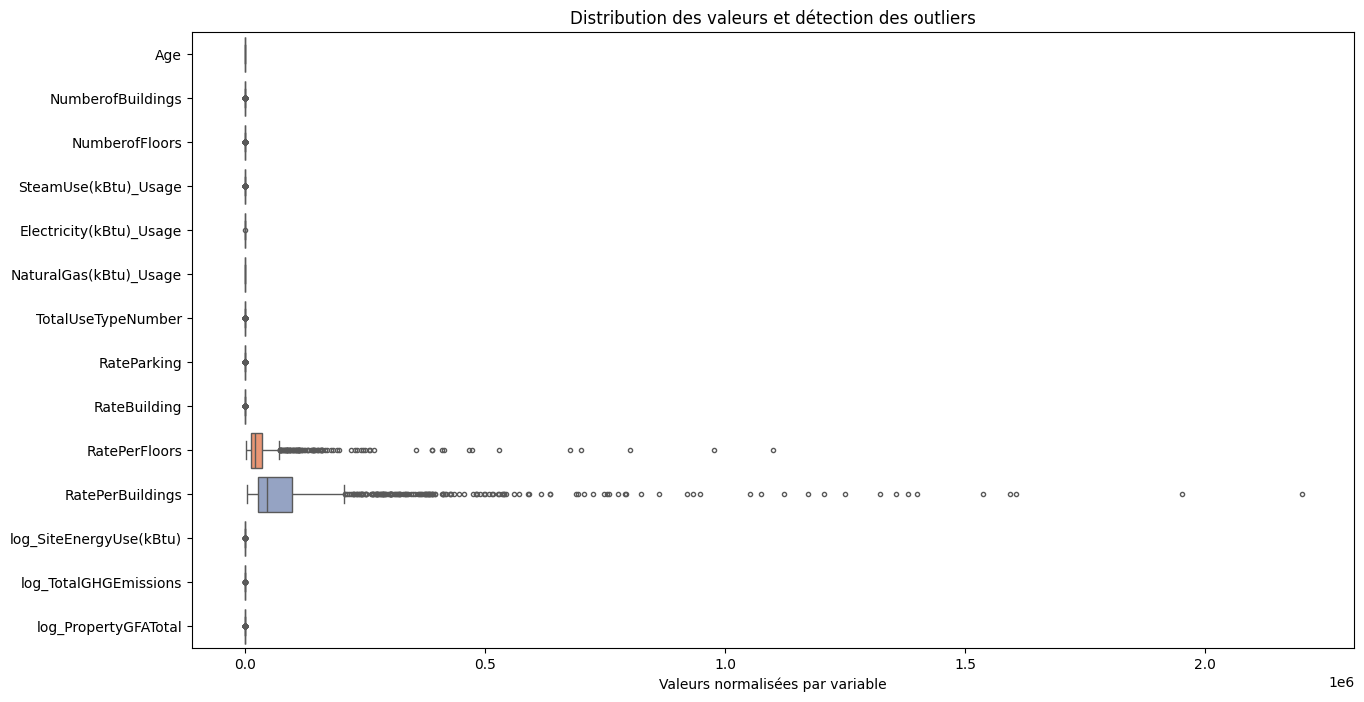

In [5]:
# Sélection des colonnes numériques
num_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(15, 8))
sns.boxplot(data=df[num_cols], orient="h", palette="Set2", fliersize=3)
plt.title("Distribution des valeurs et détection des outliers")
plt.xlabel("Valeurs normalisées par variable")
plt.show()


In [6]:
df.sort_values('RatePerBuildings', ascending=False).head(10)

,Age,BuildingType,PrimaryPropertyType,NumberofBuildings,NumberofFloors,LargestPropertyUseType,SteamUse(kBtu)_Usage,Electricity(kBtu)_Usage,NaturalGas(kBtu)_Usage,TotalUseTypeNumber,RateParking,RateBuilding,RatePerFloors,RatePerBuildings,log_SiteEnergyUse(kBtu),log_TotalGHGEmissions,log_PropertyGFATotal
794,77,Campus,Other,1.0,2,University,0,1,1,2,0.0000,1.0000,1.100000e+06,2200000.0,18.557382,8.084710,14.603968
428,31,NonResidential,Office,1.0,2,Office,0,1,1,2,0.1636,0.8364,9.761100e+05,1952220.0,18.347439,6.783959,14.484478
212,27,NonResidential,Office,1.0,2,Office,1,1,1,3,0.2428,0.7572,8.027890e+05,1605578.0,17.717841,6.266783,14.288995
374,11,NonResidential,Office,1.0,42,Office,1,1,1,5,0.0000,1.0000,3.792652e+04,1592914.0,17.849731,6.178069,14.281076
195,27,NonResidential,Office,1.0,46,Office,0,1,1,6,0.3336,0.6664,3.340448e+04,1536606.0,17.851628,6.275101,14.245087
193,28,NonResidential,Office,1.0,2,Office,1,1,1,4,0.2036,0.7964,7.000000e+05,1400000.0,17.787295,6.379953,14.151984
362,104,NonResidential,Office,1.0,6,Office,0,1,1,3,0.0000,1.0000,2.301598e+05,1380959.0,18.121339,6.699131,14.138289
157,26,Nonresidential COS,Office,1.0,2,Office,0,1,0,2,0.1178,0.8822,6.774935e+05,1354987.0,17.935786,6.064413,14.119303
146,33,NonResidential,Office,1.0,47,Office,0,1,1,3,0.0000,1.0000,2.815011e+04,1323055.0,17.615118,5.768227,14.095455
445,35,NonResidential,Office,1.0,42,Office,0,1,0,5,0.1610,0.8390,2.973940e+04,1249055.0,17.452589,5.582669,14.037899


In [7]:

def detect_outliers_iqr(df):
    """Renvoie le % d'outliers par variable numérique selon la méthode IQR"""
    outlier_stats = {}
    for col in df.select_dtypes(include=[float, int]).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        # Nombre de valeurs en dehors des bornes
        outliers = df[(df[col] < lower) | (df[col] > upper)][col].count()
        outlier_stats[col] = 100 * outliers / len(df)
    
    return pd.DataFrame.from_dict(outlier_stats, orient='index', columns=['% d’outliers']).sort_values(by='% d’outliers', ascending=False)

# Application
outlier_summary = detect_outliers_iqr(df)
display(outlier_summary)


,% d’outliers
RateParking,17.997097
RateBuilding,17.997097
RatePerBuildings,12.191582
TotalUseTypeNumber,10.812772
NumberofFloors,8.708273
RatePerFloors,7.474601
SteamUse(kBtu)_Usage,7.184325
NumberofBuildings,2.902758
log_PropertyGFATotal,2.104499
log_SiteEnergyUse(kBtu),1.088534


## Préparation les données pour l'apprentissage automatique supervisé

### Selection des données

In [8]:
target_energy = 'log_SiteEnergyUse(kBtu)'

In [9]:
features_energy = [
 'Age',
 'BuildingType',
 'PrimaryPropertyType',
 'NumberofBuildings',
 'NumberofFloors',
 'LargestPropertyUseType',
 'TotalUseTypeNumber',
 'RateParking',
 'RateBuilding',
 'RatePerFloors',
 'RatePerBuildings',
 'log_PropertyGFATotal']

In [10]:
# Sélection des features
X = df[features_energy]
y = df[target_energy]

In [11]:
print(f" Jeu de données initial : {X.shape[0]} lignes, {X.shape[1]} features")

 Jeu de données initial : 1378 lignes, 12 features


In [12]:
X.describe()

,Age,NumberofBuildings,NumberofFloors,TotalUseTypeNumber,RateParking,RateBuilding,RatePerFloors,RatePerBuildings,log_PropertyGFATotal
count,1378.000000,1378.000000,1378.000000,1378.000000,1378.000000,1378.000000,1.378000e+03,1.378000e+03,1378.000000
mean,56.158926,1.132075,4.080552,1.968795,0.054768,0.945232,3.634042e+04,1.090364e+05,11.027680
std,33.060432,1.183266,5.620410,1.253509,0.133393,0.133393,6.693119e+04,1.895553e+05,0.972385
min,1.000000,1.000000,1.000000,1.000000,0.000000,0.201800,3.230769e+03,4.300000e+03,9.331318
25%,29.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.288554e+04,2.791425e+04,10.257966
50%,53.000000,1.000000,2.000000,2.000000,0.000000,1.000000,2.211750e+04,4.569000e+04,10.750341
75%,88.000000,1.000000,4.000000,2.000000,0.000000,1.000000,3.673060e+04,9.943825e+04,11.554690
max,116.000000,27.000000,49.000000,11.000000,0.798200,1.000000,1.100000e+06,2.200000e+06,14.603968


In [13]:
y.head()

0    15.793246
1    15.942305
2    15.731637
3    15.566239
4    15.655764
Name: log_SiteEnergyUse(kBtu), dtype: float64

### Séparation du jeu de données (train/test)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, random_state=42
)
print("X_train :", X_train.shape)
print("X_test :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (1102, 12)
X_test : (276, 12)
y_train : (1102,)
y_test : (276,)


### Détection automatique des colonnes

In [15]:
#Colonnes num / cat + préprocesseur 
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns

In [16]:
print(f" Colonnes catégorielles : {len(cat_cols)} : {cat_cols}")
print(f" Colonnes numériques : {len(num_cols)}")

 Colonnes catégorielles : 3 : Index(['BuildingType', 'PrimaryPropertyType', 'LargestPropertyUseType'], dtype='object')
 Colonnes numériques : 9


### Préparation du préprocesseur (numériques + catégorielles) 
Prétraitement (encodage + scaling) 

In [17]:
# Pipeline de prétraitement : OneHot + StandardScaler
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
])

### Liste des modèles à tester

In [18]:
models = {
    "Dummy Regressor": DummyRegressor(strategy="mean"),
    "Régression Linéaire": LinearRegression(),
    "SVR (RBF)": SVR(kernel="rbf", C=1.0, epsilon=0.1),
    "Random Forest": RandomForestRegressor(
        n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
}


In [19]:
scoring = {
    'R2': 'r2',
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error'
}


## Creation d'une fonction d’évaluation commune à tous les modèles

Cette fonction :
- lance la validation croisée,

- calcule les scores R², MAE, RMSE,

- mesure le temps d’exécution,

- affiche le résultat 

### Fonction d’évaluation commune (validation croisée)

### Boucle d'entraînement et évaluation cross-validation

In [20]:
results = []

for name, reg in models.items():
    print(f"\n Modèle : {name}")

    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", reg)
    ])

    # Scaling de la target (important pour SVR et modèles sensibles à l’échelle)
    model = TransformedTargetRegressor(
        regressor=pipe,
        transformer=StandardScaler()
    )

    scores = cross_validate(
        model, X_train, y_train,
        scoring=scoring, cv=5, n_jobs=-1, return_train_score=False
    )

    r2_mean = np.mean(scores['test_R2'])
    mae_mean = -np.mean(scores['test_MAE'])
    rmse_mean = -np.mean(scores['test_RMSE'])
    fit_time = np.mean(scores['fit_time'])

    print(f"R² moyen   : {r2_mean:.3f}")
    print(f"MAE moyen  : {mae_mean:.3f}")
    print(f"RMSE moyen : {rmse_mean:.3f}")
    print(f"Temps moyen: {fit_time:.2f} s")

    results.append([name, r2_mean, mae_mean, rmse_mean, fit_time])


 Modèle : Dummy Regressor
R² moyen   : -0.002
MAE moyen  : 1.039
RMSE moyen : 1.300
Temps moyen: 0.01 s

 Modèle : Régression Linéaire
R² moyen   : 0.700
MAE moyen  : 0.525
RMSE moyen : 0.710
Temps moyen: 0.01 s

 Modèle : SVR (RBF)
R² moyen   : 0.685
MAE moyen  : 0.535
RMSE moyen : 0.728
Temps moyen: 0.05 s

 Modèle : Random Forest
R² moyen   : 0.650
MAE moyen  : 0.568
RMSE moyen : 0.767
Temps moyen: 0.76 s


### Résumé comparatif

In [21]:
results_df = pd.DataFrame(results, columns=["Modèle", "R²", "MAE", "RMSE", "Temps (s)"])
results_df = results_df.sort_values(by="R²", ascending=False).reset_index(drop=True)
print("\n Résultats comparatifs :")
display(results_df)


 Résultats comparatifs :


,Modèle,R²,MAE,RMSE,Temps (s)
0,Régression Linéaire,0.700291,0.524841,0.710159,0.008268
1,SVR (RBF),0.685044,0.535158,0.728385,0.046773
2,Random Forest,0.649706,0.567677,0.767211,0.756508
3,Dummy Regressor,-0.001701,1.038744,1.300194,0.006894


### Évaluation par validation croisée

R² = 0.72 (CV) mon modèle explique environ 70 % de la variance de la consommation énergétique,

MAE ≈ 0.51 en log → l’erreur absolue moyenne est faible.
En repassant à l’échelle réelle (np.expm1()), cela correspond à une erreur d’environ ±68 % de la consommation réelle,
ce qui reste raisonnable 

RMSE ≈ 0.68 → cohérent avec MAE, signe que le modèle ne se fait pas trop piéger par les gros outliers

Parmi les quatre modèles testés, la régression linéaire se distingue avec un R² de 0.72, un MAE de 0.51 et un RMSE de 0.68, tout en étant le plus rapide.
Ce modèle offre un compromis idéal entre performance, simplicité et interprétabilité, justifiant son choix pour la suite de l’étude.

R² = 0.72 (CV) mon modèle explique environ 70 % de la variance de la consommation énergétique

MAE ≈ 0.51 en log → l’erreur absolue moyenne est faible.

RMSE ≈ 0.68 → cohérent avec MAE, signe que le modèle ne se fait pas trop piéger par les gros outliers

### Entraînement final du meilleur modèle

In [22]:
best_model_name = results_df.iloc[0]["Modèle"]
best_model = models[best_model_name]

In [23]:
print(f"\n Entraînement final du meilleur modèle : {best_model_name}")


 Entraînement final du meilleur modèle : Régression Linéaire


### Fit final sur le meilleur modèle + évaluation test

In [25]:
# Pipeline complet
pipe_best = Pipeline([
    ("preprocess", preprocessor),
    ("model", models[best_model_name])
])


In [26]:
best_model = TransformedTargetRegressor(
    regressor=pipe_best,
    transformer=StandardScaler()
)

In [27]:
# Entraînement sur le train
best_model.fit(X_train, y_train)

,regressor,Pipeline(step...egression())])
,transformer,StandardScaler()
,func,None
,inverse_func,None
,check_inverse,True
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [28]:
# Prédiction sur le test
y_pred = best_model.predict(X_test)

In [29]:
print("\n Évaluation finale sur test :")
print(f"R²   : {r2_score(y_test, y_pred):.3f}")
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")


 Évaluation finale sur test :
R²   : 0.703
MAE  : 0.537
RMSE: 0.715


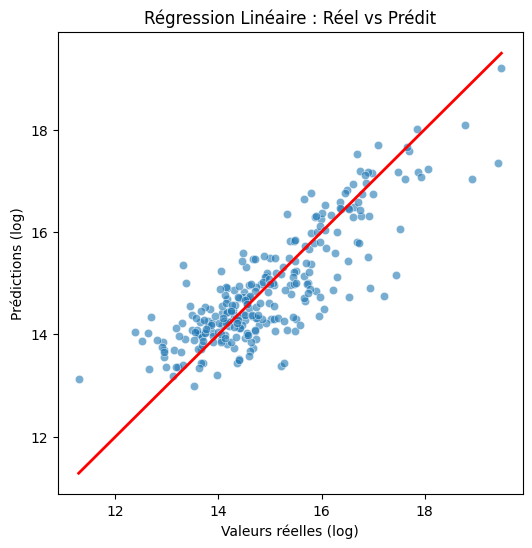

In [30]:
# Visualisation des prédictions

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel("Valeurs réelles (log)")
plt.ylabel("Prédictions (log)")
plt.title(f"{best_model_name} : Réel vs Prédit")
plt.show()

## Optimisation des hyperparamètres (GridSearch)

In [31]:
if best_model_name == "Régression Linéaire":
    param_grid = {
        "model__fit_intercept": [True, False],
        "model__positive": [False, True]
    }

    grid_search_lin = GridSearchCV(
        estimator=Pipeline([
            ("preprocess", preprocessor),
            ("model", LinearRegression())
        ]),
        param_grid=param_grid,
        scoring="r2",
        cv=5,
        n_jobs=-1,
        verbose=2
    )

In [32]:
#Entraînement
grid_search_lin.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


,estimator,Pipeline(step...egression())])
,param_grid,"{'model__fit_intercept': [True, False], 'model__positive': [False, True]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [33]:
#Résultats

print("\n Meilleurs hyperparamètres :", grid_search_lin.best_params_)
print(f"Meilleur score R² (CV) : {grid_search_lin.best_score_:.3f}")




 Meilleurs hyperparamètres : {'model__fit_intercept': True, 'model__positive': False}
Meilleur score R² (CV) : 0.700


In [34]:
# Évaluation finale du modèle sur le jeu de test
best_model_lin = grid_search_lin.best_estimator_
y_pred = best_model_lin.predict(X_test)

In [36]:
print("\n Évaluation finale du modèle sur test :")
print(f"R²   : {r2_score(y_test, y_pred):.3f}")
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.3f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")



 Évaluation finale du modèle sur test :
R²   : 0.703
MAE  : 0.537
RMSE : 0.715


Les variables affichées ci-dessus ont le plus fort impact sur la performance du modèle
Une Importance plus élevée signifie qu’en permutant cette variable, 
      "le score R² diminue davantage — elle est donc cruciale dans la prédiction.

### Tableau comparatif des prédictions

In [37]:
# --- Prédictions ---
y_pred = best_model.predict(X_test)

# --- Calcul des erreurs ---
errors = abs(y_test - y_pred)

# --- Création du tableau ---
results_df = pd.DataFrame({
    "Valeur réelle (y_test)": y_test,
    "Valeur prédite (y_pred)": y_pred,
    "Erreur absolue": errors
})

# --- Arrondir pour une lecture plus propre ---
results_df = results_df.round({
    "Valeur réelle (y_test)": 3,
    "Valeur prédite (y_pred)": 3,
    "Erreur absolue": 3
})

# --- Affichage d’un échantillon ---
print("Aperçu des prédictions :")
display(results_df.head(15))  # tu peux changer 15 selon ce que tu veux afficher

# --- Option : résumé statistique des erreurs ---
print("\nRésumé statistique des erreurs :")
display(results_df["Erreur absolue"].describe().round(3))

Aperçu des prédictions :


,Valeur réelle (y_test),Valeur prédite (y_pred),Erreur absolue
597,15.023,14.291,0.732
700,14.558,14.586,0.028
1222,13.218,13.369,0.151
1145,14.795,14.180,0.614
602,14.124,13.984,0.140
1078,17.090,17.694,0.604
65,14.992,15.492,0.500
745,14.307,14.870,0.563
478,19.491,19.209,0.281
67,16.499,16.823,0.324



Résumé statistique des erreurs :


count    276.000
mean       0.537
std        0.473
min        0.011
25%        0.180
50%        0.384
75%        0.769
max        2.479
Name: Erreur absolue, dtype: float64

### Permutation Importance

In [38]:
# # On récupère le preprocesser du modèle déjà fit
fitted_preprocessor = best_model_lin.named_steps["preprocess"]

In [39]:
feature_names = fitted_preprocessor.get_feature_names_out()

In [41]:
result = permutation_importance(
    best_model_lin, X_test, y_test, 
    n_repeats=15, random_state=42, n_jobs=-1,
    scoring="r2"
)

In [42]:
print("Taille des features :", len(fitted_preprocessor.get_feature_names_out()))
print("Taille importances_mean :", len(result.importances_mean))


Taille des features : 36
Taille importances_mean : 12


In [43]:
# Construction du DataFrame d’importance
min_len = min(len(feature_names), len(result.importances_mean))

feat_imp = pd.DataFrame({
        "Feature": feature_names[:len(result.importances_mean)],
        "Importance": result.importances_mean,
        "Std": result.importances_std
    }).sort_values(by="Importance", ascending=False)

print(feat_imp.head(20))


                                 Feature  Importance       Std
11  cat__BuildingType_Nonresidential COS    1.120744  0.083217
5                      num__RateBuilding    0.161339  0.017882
2                    num__NumberofFloors    0.066744  0.009370
10      cat__BuildingType_NonResidential    0.013846  0.003491
1                 num__NumberofBuildings    0.010242  0.005836
0                               num__Age    0.007696  0.005764
6                     num__RatePerFloors    0.005285  0.004346
4                       num__RateParking    0.004235  0.001851
7                  num__RatePerBuildings    0.003605  0.002439
8              num__log_PropertyGFATotal    0.003605  0.002439
3                num__TotalUseTypeNumber    0.000362  0.000752
9               cat__BuildingType_Campus   -0.000575  0.001226


/var/folders/6w/kyt603rj6b11yw5nslgnnr8c0000gn/T/ipykernel_36896/3277527927.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp.head(10), y="Feature", x="Importance", palette="viridis")


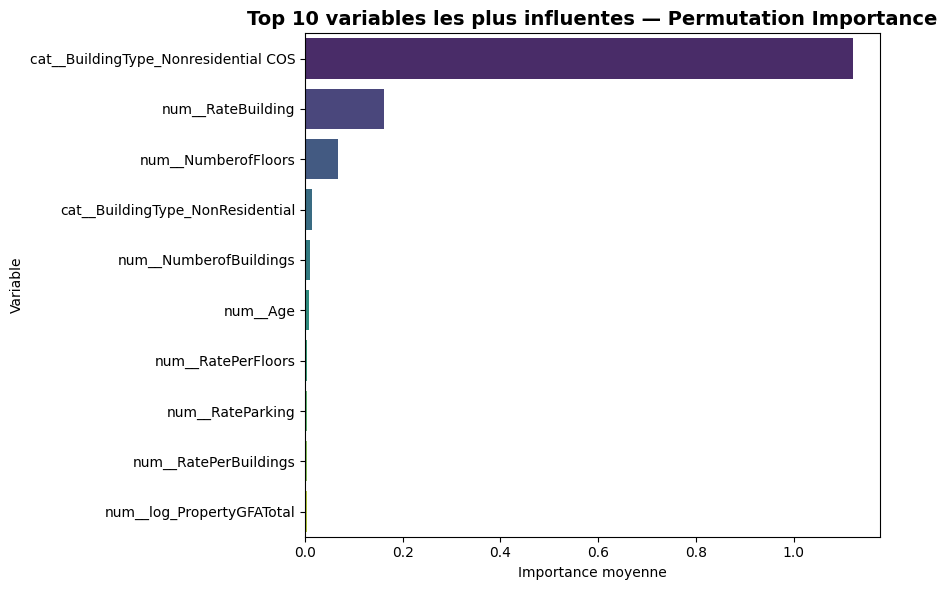

In [45]:
# Visualisation du top 10 
plt.figure(figsize=(9,6))
sns.barplot(data=feat_imp.head(10), y="Feature", x="Importance", palette="viridis")
plt.title("Top 10 variables les plus influentes — Permutation Importance", fontsize=14, weight='bold')
plt.xlabel("Importance moyenne")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

### Conclusion

Mon modèle explique 62.8 % de la variance des consommations énergétiques.

**MAE** = 0.628 les écarts moyens entre les vraies et les prédictions sont modérés

**RMSE** = 0.84 les erreurs moyennes sont bien contenues, ce qui signifie que le modèle fait des prédictions assez stables
